# Emotion Detection with YOLOv8 (Classification) on FER2013

Pipeline untuk melatih model klasifikasi emosi wajah menggunakan YOLOv8-cls pada dataset FER2013.

## Alur
1. Visualisasi dataset: satu gambar acak per kelas emosi.
2. Siapkan dataset untuk YOLO classification: split train 85% / val 15%, susun ke struktur folder per-kelas.
3. Training: muat YOLOv8n-cls dan latih pada dataset.

FER2013 berisi gambar wajah yang sudah ter-crop (satu emosi per gambar), sehingga ini adalah tugas klasifikasi, bukan deteksi objek.

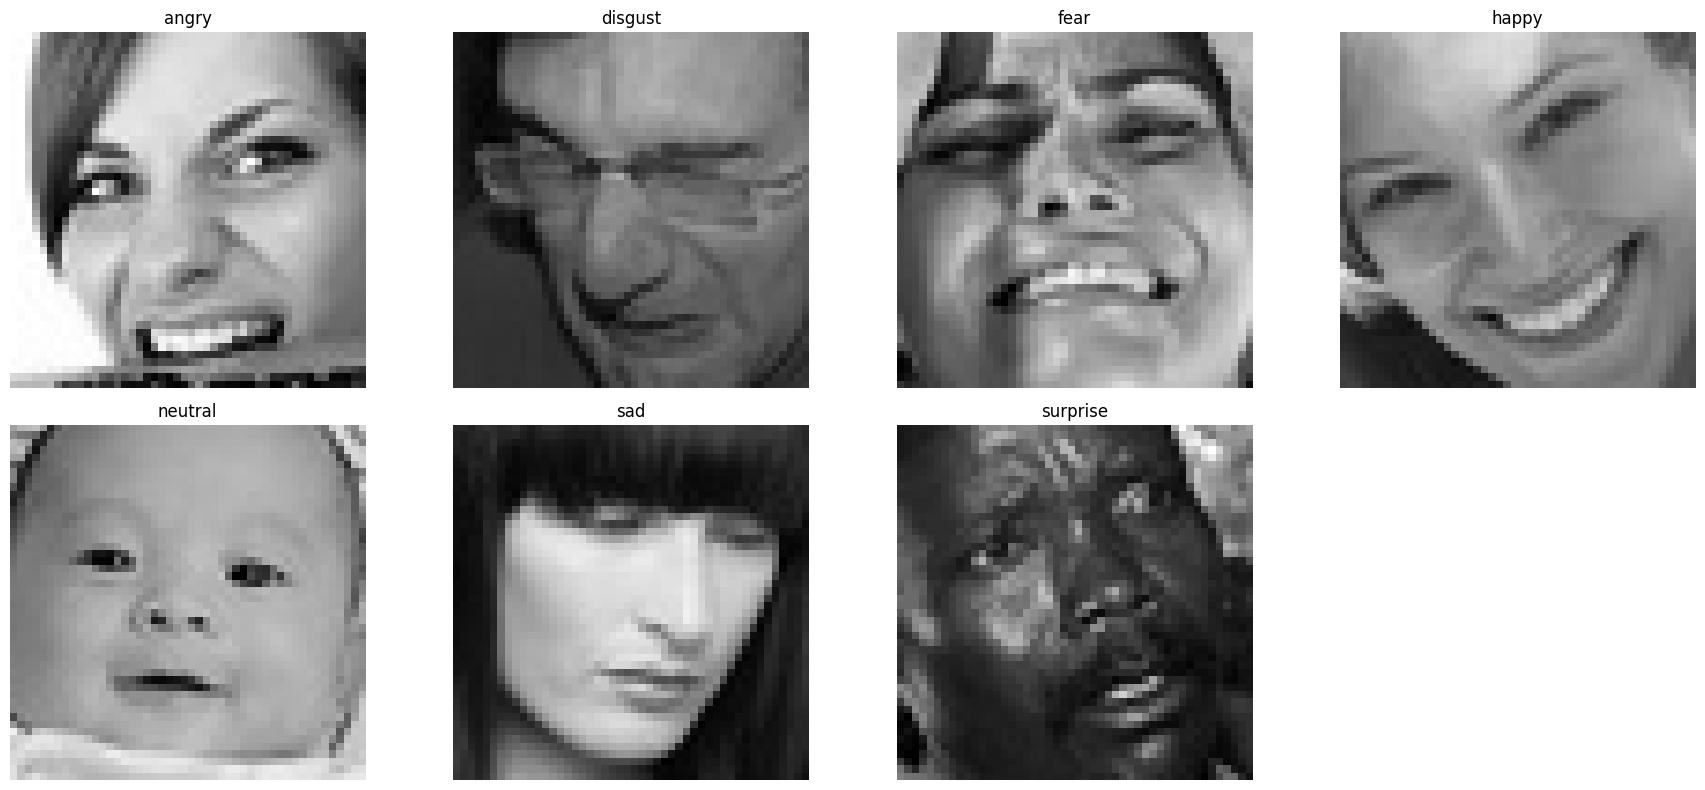

In [1]:
import matplotlib.pyplot as plt
import cv2
import os
import random

# fer2013 base path
fer_input_path = "/kaggle/input/datasets/msambare/fer2013/train"

classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# show one image per class
plt.figure(figsize=(18, 8))

for i, cls_name in enumerate(classes):
    class_dir = os.path.join(fer_input_path, cls_name)
    image_files = os.listdir(class_dir)
    img_file = random.choice(image_files)

    img_path = os.path.join(class_dir, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(cls_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Visualisasi satu gambar per kelas

Menampilkan satu gambar acak dari tiap kelas emosi (angry, disgust, fear, happy, neutral, sad, surprise) untuk mengecek struktur dan kualitas data sebelum training.

In [2]:
import os, shutil, glob, random

base_input = "/kaggle/input/datasets/msambare/fer2013"
base_output = "/kaggle/working/FER_YOLO"

classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# build per-class folders for classification
for split in ['train', 'val']:
    for cls_name in classes:
        os.makedirs(os.path.join(base_output, split, cls_name), exist_ok=True)

## Struktur folder untuk YOLO classification

Membuat folder dataset bergaya klasifikasi: `train/<emotion>/` dan `val/<emotion>/`. Mode classification tidak memerlukan file label; kelas ditentukan dari nama folder.

In [3]:
for cls_name in classes:
    image_paths = glob.glob(f"{base_input}/train/{cls_name}/*.jpg")
    assert len(image_paths) > 0, f"Kosong: {cls_name} di {base_input}/train/{cls_name}"
    random.shuffle(image_paths)

    split_idx = int(0.85 * len(image_paths))
    splits = {
        'train': image_paths[:split_idx],
        'val': image_paths[split_idx:],
    }

    for split, paths in splits.items():
        for img_path in paths:
            fname = os.path.basename(img_path)
            out_img = os.path.join(base_output, split, cls_name, fname)
            shutil.copy(img_path, out_img)

## Split dan penyalinan gambar

Untuk tiap kelas: ambil semua gambar, acak, lalu bagi 85% train / 15% val. Gambar disalin ke folder kelas masing-masing. Tidak ada file label karena mode classification membaca kelas dari struktur folder.

In [4]:
# dataset root passed directly to yolo classification
dataset_path = base_output

## Path dataset

YOLOv8 classification cukup diarahkan ke folder root dataset (yang berisi `train/` dan `val/`). Tidak diperlukan file `data.yaml` seperti pada mode detection.

In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 71.1 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1

Installing needed Library to import YOLO

In [6]:
from ultralytics import YOLO

# load classification model
model = YOLO("yolov8n-cls.pt")

# train
results = model.train(
    data=dataset_path,
    epochs=50,
    imgsz=64,
    batch=64,
    workers=0,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/FER_YOLO, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=

## Training YOLOv8-cls pada FER2013

Memuat model `yolov8n-cls.pt` (varian classification yang ringan) dan melatihnya pada dataset.

- `data`: folder root dataset (berisi `train/` dan `val/`).
- `epochs`: jumlah epoch (50).
- `imgsz`: ukuran input (64, menyesuaikan gambar FER2013 yang kecil).
- `batch`: ukuran batch (64).
- `workers`: 0 untuk kompatibilitas (Kaggle/Windows).

Setelah training, bobot terbaik tersimpan di `runs/classify/train/weights/best.pt`. Unduh file itu untuk dipakai di tahap apply.